# Bussiness problem


# Step 1: Import Libraries

In [152]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the Dataset

In [3]:
df=pd.read_csv(r"C:\Users\rithikagogi\Downloads\archive (14)\Flipkart_Mobiles.csv")
df.head()

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price
0,OPPO,A53,Moonlight Black,4 GB,64 GB,4.5,11990,15990
1,OPPO,A53,Mint Cream,4 GB,64 GB,4.5,11990,15990
2,OPPO,A53,Moonlight Black,6 GB,128 GB,4.3,13990,17990
3,OPPO,A53,Mint Cream,6 GB,128 GB,4.3,13990,17990
4,OPPO,A53,Electric Black,4 GB,64 GB,4.5,11990,15990


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3114 entries, 0 to 3113
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           3114 non-null   object 
 1   Model           3114 non-null   object 
 2   Color           3114 non-null   object 
 3   Memory          3071 non-null   object 
 4   Storage         3075 non-null   object 
 5   Rating          2970 non-null   float64
 6   Selling Price   3114 non-null   int64  
 7   Original Price  3114 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 194.8+ KB


In [6]:
df.shape

(3114, 8)

In [7]:
df.describe()

,Rating,Selling Price,Original Price
count,2970.000000,3114.000000,3114.000000
mean,4.243098,26436.625562,28333.473025
std,0.271991,30066.892622,31525.599889
min,2.300000,1000.000000,1000.000000
25%,4.100000,9990.000000,10030.250000
50%,4.300000,15000.000000,16889.500000
75%,4.400000,28999.000000,31500.000000
max,5.000000,179900.000000,189999.000000


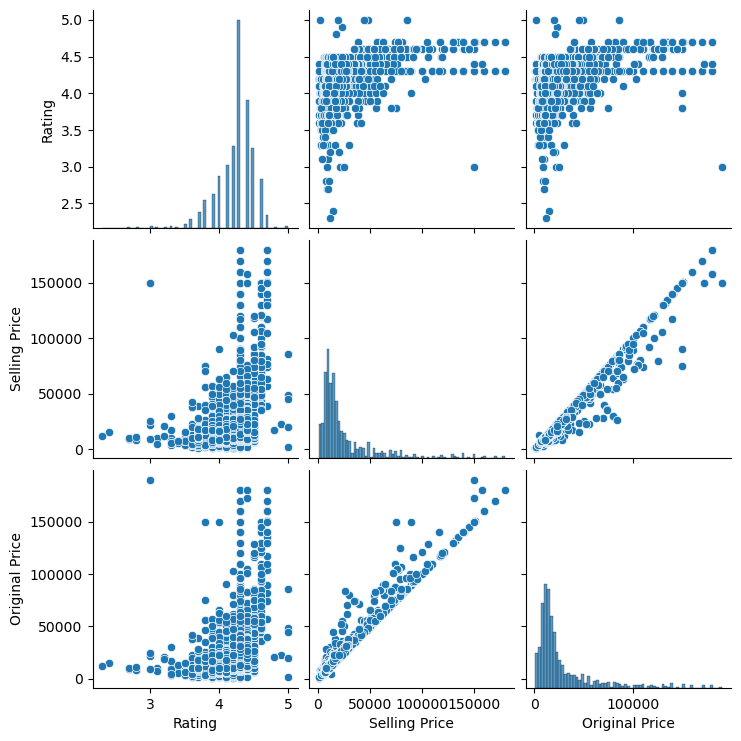

In [10]:
sns.pairplot(df)
plt.show()

In [8]:
df.isnull().sum()

Brand               0
Model               0
Color               0
Memory             43
Storage            39
Rating            144
Selling Price       0
Original Price      0
dtype: int64

In [15]:
df['Memory'] = df['Memory'].fillna(df['Memory'].mode()[0])
df['Storage'] = df['Storage'].fillna(df['Storage'].mode()[0])
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

In [16]:
df.isnull().sum()

Brand             0
Model             0
Color             0
Memory            0
Storage           0
Rating            0
Selling Price     0
Original Price    0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(118)

In [18]:
df = df.drop_duplicates()

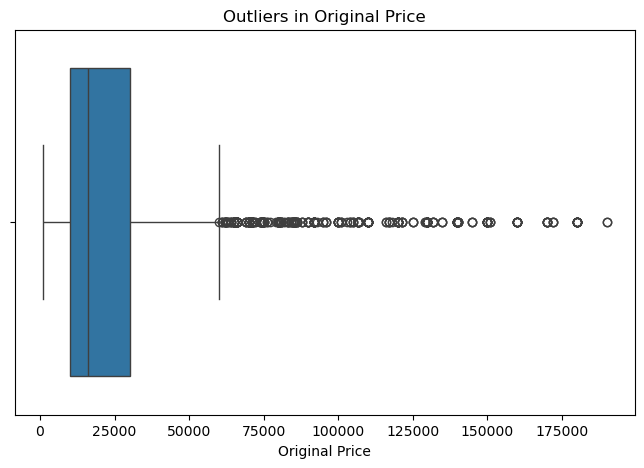

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Original Price'])
plt.title('Outliers in Original Price')
plt.show()

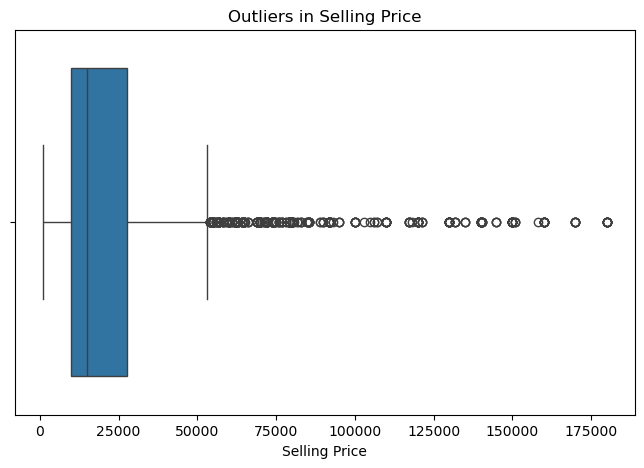

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Selling Price'])
plt.title('Outliers in Selling Price')
plt.show()

# Relationship btw X and Y

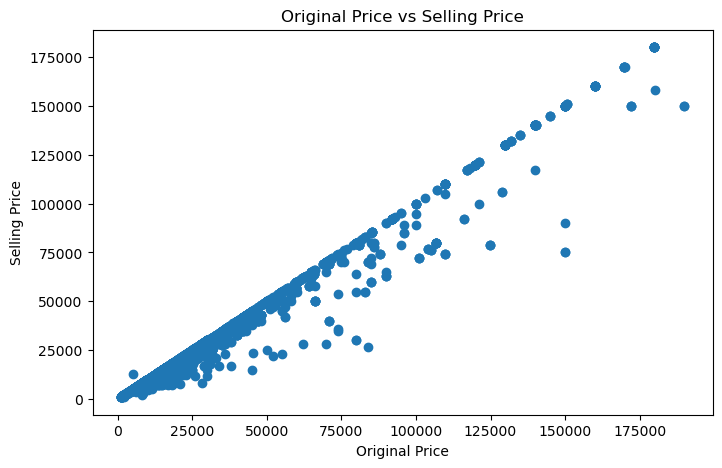

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(df['Original Price'], df['Selling Price'])
plt.xlabel('Original Price')
plt.ylabel('Selling Price')
plt.title('Original Price vs Selling Price')
plt.show()

In [23]:
df[['Original Price', 'Selling Price']].corr()

,Original Price,Selling Price
Original Price,1.000000,0.985779
Selling Price,0.985779,1.000000


 # SIMPLE LINEAR REGRESSION

In [63]:
x = df[['Original Price']]

y = df['Selling Price']

In [ ]:
# Train and test split data

In [30]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (2396, 1)
x_test: (600, 1)
y_train: (2396,)
y_test: (600,)


In [50]:
# create model
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
# Train and test accuracy

In [52]:
#training prediction
y_train_pred =model.predict(x_train)
#testing prediction
y_test_pred =model.predict(x_test)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
print("Training R2 Score:", train_r2)
print("Testing R2 Score:", test_r2)

Training R2 Score: 0.9741791070526108
Testing R2 Score: 0.9596026701086479


In [57]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: -259.97764561426084
Coefficient: 0.9434501563282991


In [42]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_test_pred)
print("MAE:", mae)

MAE: 2506.358354015563


In [44]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_test_pred)
print("MSE:", mse)

MSE: 29807486.06405065


In [45]:
import numpy as np

rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 5459.623252940687


In [47]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_test_pred)
print("R2 Score:", r2)

R2 Score: 0.9596026701086479


In [48]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 2506.358354015563
MSE : 29807486.06405065
RMSE: 5459.623252940687
R2  : 0.9596026701086479


In [56]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,x,y,cv=5)
print(scores)

[0.90594724 0.99003215 0.97316166 0.86743936 0.99152224]


In [58]:
print("Cross Validation Score:",scores.mean())

Cross Validation Score: 0.945620532473533


In [59]:
df[['Original Price', 'Selling Price']].corr()

,Original Price,Selling Price
Original Price,1.000000,0.985779
Selling Price,0.985779,1.000000


In [60]:
import statsmodels.formula.api as smf
model2=smf.ols("y~x",data=df).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                 1.030e+05
Date:                Wed, 02 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:17:56   Log-Likelihood:                -29763.
No. Observations:                2996   AIC:                         5.953e+04
Df Residuals:                    2994   BIC:                         5.954e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -202.5879    122.157     -1.658      0.097    -442.108      36.932
x              0.9396      0.003    320.982      0.000       0.934       0.945
==============================================================================
Omnibus:                     3098.393   Durbin-Watson:                   1.715
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           244589.796
Skew:                          -5.014   Prob(JB):                         0.00
Kurtosis:                      46.114   Cond. No.                     5.59e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.59e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [61]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
print("Intercept:",model.intercept_)
print("coefficient:", model.coef_)
print("Train R2:",model.score(x_train,y_train))
print("Test R2:",r2_score(x_test,y_test))
print("Cross Validation Score:",scores.mean())

Intercept: -259.97764561426084
coefficient: [0.94345016]
Train R2: 0.9741791070526108
Test R2: 0.9536379478458543
Cross Validation Score: 0.945620532473533


In [62]:
new_phone = pd.DataFrame({
    'Original Price': [30000]
})

predicted_price = model.predict(new_phone)

print("Expected Selling Price:", predicted_price[0])

Expected Selling Price: 28043.527044234714


# MULTI LINEAR REGRESSION MODEL

In [64]:
df[['Original Price', 'Rating', 'Memory', 'Storage', 'Selling Price']].head()

,Original Price,Rating,Memory,Storage,Selling Price
0,15990,4.5,4 GB,64 GB,11990
1,15990,4.5,4 GB,64 GB,11990
2,17990,4.3,6 GB,128 GB,13990
3,17990,4.3,6 GB,128 GB,13990
4,15990,4.5,4 GB,64 GB,11990


In [65]:
print(df['Memory'].unique())
print(df['Storage'].unique())

['4 GB' '6 GB' '3 GB' '8 GB' '2 GB' '12 GB' '1 GB' '512 MB' '1.5 GB'
 '768 MB' '16 GB' '18 GB' '8 MB' '64 MB' '4 MB' '32 MB' '16 MB' '128 MB'
 '4GB' '153 MB' '2 MB' '10 MB' '46 MB' '32 GB' '100 MB' '30 MB']
['64 GB' '128 GB' '32 GB' '256 GB' '16 GB' '8 GB' '4 GB' '512 GB' '16 MB'
 '128 MB' '2 MB' '4 MB' '48 MB' '8 MB' 'Expandable Upto 32 GB'
 'Expandable Upto 16 GB' '10 MB' '256 MB' '140 MB' '64 MB' '1 TB' '153 MB'
 '512 MB' '100 MB' '129 GB' '130 GB']


In [71]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_columns = [ 'Memory', 'Storage']
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

C:\Users\rithikagogi\AppData\Local\Temp\ipykernel_9660\3233749530.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col])
C:\Users\rithikagogi\AppData\Local\Temp\ipykernel_9660\3233749530.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = le.fit_transform(df[col])


In [70]:
df.head()

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price
0,OPPO,A53,Moonlight Black,4,20,4.5,11990,15990
1,OPPO,A53,Mint Cream,4,20,4.5,11990,15990
2,OPPO,A53,Moonlight Black,5,3,4.3,13990,17990
3,OPPO,A53,Mint Cream,5,3,4.3,13990,17990
4,OPPO,A53,Electric Black,4,20,4.5,11990,15990


In [72]:
x = df[['Original Price', 'Rating', 'Memory', 'Storage']]
y = df['Selling Price']

In [73]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [74]:
print("X Train:", x_train.shape)
print("X Test:", x_test.shape)
print("Y Train:", y_train.shape)
print("Y Test:", y_test.shape)

X Train: (2396, 4)
X Test: (600, 4)
Y Train: (2396,)
Y Test: (600,)


In [77]:
from sklearn.linear_model import LinearRegression
model_multi = LinearRegression()
model_multi.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [81]:
#training prediction
y_train_pred =model_multi.predict(x_train)
#testing prediction
y_test_pred =model_multi.predict(x_test)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
print("Training R2 Score:", train_r2)
print("Testing R2 Score:", test_r2)

Training R2 Score: 0.9744541962220765
Testing R2 Score: 0.9601493085152775


In [82]:
print("Intercept:", model_multi.intercept_)
print("Coefficient:", model_multi.coef_[0])

Intercept: -3968.2052631297083
Coefficient: 0.9425481719678536


In [83]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 2506.358354015563
MSE : 29807486.06405065
RMSE: 5459.623252940687
R2  : 0.9596026701086479


In [84]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,x,y,cv=5)
print(scores)

[0.90732915 0.98989143 0.97336064 0.86869671 0.99172913]


In [85]:
print("Cross Validation Score:",scores.mean())

Cross Validation Score: 0.9462014114618202


In [91]:
df[['Original Price', 'Rating', 'Memory', 'Storage']].corr()

,Original Price,Rating,Memory,Storage
Original Price,1.000000,0.400423,0.079814,-0.150295
Rating,0.400423,1.000000,0.015792,-0.138158
Memory,0.079814,0.015792,1.000000,-0.152381
Storage,-0.150295,-0.138158,-0.152381,1.000000


In [94]:
import statsmodels.formula.api as smf
model_stats = smf.ols(
    'Q("Selling Price") ~ Q("Original Price") + Rating + Memory + Storage',
    data=df
).fit()

print(model_stats.summary())

                            OLS Regression Results                            
Dep. Variable:     Q("Selling Price")   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                 2.604e+04
Date:                Wed, 02 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:43:17   Log-Likelihood:                -29745.
No. Observations:                2996   AIC:                         5.950e+04
Df Residuals:                    2991   BIC:                         5.953e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -4117.8887   1

In [99]:
import pandas as pd

input_data = pd.DataFrame({
    'Original Price': [40000],
    'Rating': [4.3],
    'Memory': [8],
    'Storage': [128]
})

predicted_price = model_multi.predict(input_data)

print("Expected Selling Price:", predicted_price[0])

Expected Selling Price: 41825.898953753596


# Polynomial regression

In [135]:
x = df[['Original Price']]

y = df['Selling Price']

In [136]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [137]:
# Default model

In [138]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_converter=PolynomialFeatures(degree=2,include_bias=False)
x_train=pd.DataFrame(polynomial_converter.fit_transform(x_train))
x_test=pd.DataFrame(polynomial_converter.transform(x_test))
x_poly=polynomial_converter.fit_transform(x)
x_poly=pd.DataFrame(x_poly)

In [139]:
x

,Original Price
0,15990
1,15990
2,17990
3,17990
4,15990
...,...
3109,25990
3110,28449
3111,31489
3112,22989


In [140]:
y

0       11990
1       11990
2       13990
3       13990
4       11990
        ...  
3109    25990
3110    25489
3111    27239
3112    22989
3113    20350
Name: Selling Price, Length: 2996, dtype: int64

In [141]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [142]:
model.intercept_

np.float64(465.2622567219332)

In [143]:
# Hyper parameter tuning

In [144]:
train_r2=[]
test_r2=[]
for i in range(1,10):
    from sklearn.preprocessing import PolynomialFeatures
    polynomial_converter=PolynomialFeatures(degree=i,include_bias=False)
    x_poly=polynomial_converter.fit_transform(x)
    x_poly=pd.DataFrame(x_poly)
    from sklearn.model_selection import train_test_split

    x_train, x_test, y_train, y_test = train_test_split( x_poly, y, test_size=0.3, random_state=42)
    from sklearn.linear_model import LinearRegression
    model = LinearRegression()
    model.fit(x_train,y_train)
    test_pred=model.predict(x_test)
    train_pred=model.predict(x_train)
    test_r2.append(model.score(x_test,y_test))
    train_r2.append(model.score(x_train,y_train))

In [145]:
train_r2

[0.9782610009307282,
 0.9788927048167618,
 0.9789230504648515,
 0.9700762522996396,
 0.9385380444400777,
 0.8916293312913641,
 0.8393445115484073,
 0.6480048437341077,
 0.6004131209258878]

In [146]:
test_r2

[0.9515257988326196,
 0.9508308698625803,
 0.950808730059351,
 0.9402025288764022,
 0.8981790681863323,
 0.8335614201484931,
 0.7587668289078296,
 0.4956708990061648,
 0.43745802685670965]

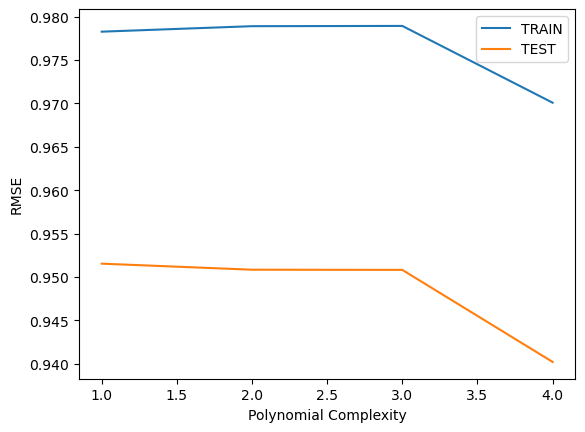

In [147]:
plt.plot(range(1,5),train_r2[:4],label="TRAIN")
plt.plot(range(1,5),test_r2[:4],label="TEST")
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.legend()
plt.show()

In [148]:
# Rebuilt model

In [149]:
final_poly_converter=PolynomialFeatures(degree=3,include_bias=False)
x_poly=final_poly_converter.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split( x_poly, y, test_size=0.3, random_state=42)
final_model=LinearRegression()
final_model.fit(x_train,y_train)
train_pred=final_model.predict(x_train)
test_pred=final_model.predict(x_test)
print("Train R2:",final_model.score(x_train,y_train)) 
print("Test R2:",final_model.score(x_test,y_test))

Train R2: 0.9789230504648515
Test R2: 0.950808730059351


In [150]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))
print("MAE:", mean_absolute_error(y_test, test_pred))
print("MSE:", mean_squared_error(y_test, test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))
print("R2 Score:", r2_score(y_test, test_pred))

Train R2: 0.9789230504648515
Test R2: 0.950808730059351
MAE: 2518.781633997298
MSE: 36152343.02407648
RMSE: 6012.681849564009
R2 Score: 0.950808730059351


In [151]:
new_mobile = pd.DataFrame({
    'Original Price': [20000]
})

# Convert into polynomial features
new_mobile_poly = final_poly_converter.transform(new_mobile)

# Predict Selling Price
predicted_price = final_model.predict(new_mobile_poly)

print("Original Price:", 20000)
print("Predicted Selling Price:", predicted_price[0])

Original Price: 20000
Predicted Selling Price: 18573.191847350743
